In [2]:
import os
import rasterio
import rioxarray as rxr
from matplotlib.pyplot import savefig
from scipy.stats import linregress
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import glob
from pathlib import Path
from rasterio.warp import reproject, Resampling
import matplotlib.colors as mcolors
import matplotlib.cm as cm
from rasterstats import zonal_stats
import geopandas as gpd
from metloom.pointdata import SnotelPointData
from datetime import datetime
from osgeo import gdal
from shapely.geometry import Point
from pyproj import Proj, Transformer
gdal.UseExceptions()
from matplotlib.ticker import MaxNLocator
from scipy.stats import kruskal
import scikit_posthocs as sp

import importlib
import model_comparison_functions
importlib.reload(model_comparison_functions)
from model_comparison_functions import process_all_dates, get_raw_data

In [3]:
task1_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2_raw_data = get_raw_data("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)
task1 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 1)
task2 = process_all_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates", 2)


In [20]:
regressions = []

def rmse_numpy(actual, predicted):
    return np.sqrt(np.mean((predicted - actual) ** 2))

for key in task1.keys():
    lidar = task1[key]['lidar']
    resample_task1 = task1[key]['resample']
    resample_task2 = task2[key]['resample']
    
    resample = {"Task 1":resample_task1, "Task 2":resample_task2}

    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    
    for task, raster in resample.items():
        for name, model_data in raster.items():
                raster = rxr.open_rasterio(model_data, masked=True).squeeze()
        # Flatten
                x = lidar.values.flatten()
                y = raster.values.flatten()
            
                mask = ~np.isnan(x) & ~np.isnan(y)
                x_clean = x[mask]
                y_clean = y[mask]
                
                regression_result = linregress(x_clean, y_clean)
                
                rmse = rmse_numpy(x_clean, y_clean)
                
                row = {
                    "Task": task,
                    "Date": key,
                    "Model": name,
                    "slope": regression_result.slope,
                    "intercept": regression_result.intercept,
                    "rvalue": regression_result.rvalue,
                    "pvalue": regression_result.pvalue,
                    "stderr": regression_result.stderr,
                    "RMSE": rmse
                }
            
                regressions.append(row)
                
    df = pd.DataFrame(regressions)
    df['r-squared'] = df['rvalue']**2
    df.to_csv('regression_results.csv', index=False)


In [21]:
df_filtered_isno = df[(df['Model'] == 'iSnobal') | (df['Model'] == 'SnowModel')]
df_filtered_hms = df[(df['Model'] == 'HMS-Energy-Balance') | (df['Model'] == 'HMS-Temperature-Index')]

C:\Users\RDCRLSMC\AppData\Local\Temp\2\ipykernel_9440\1447745487.py:4: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


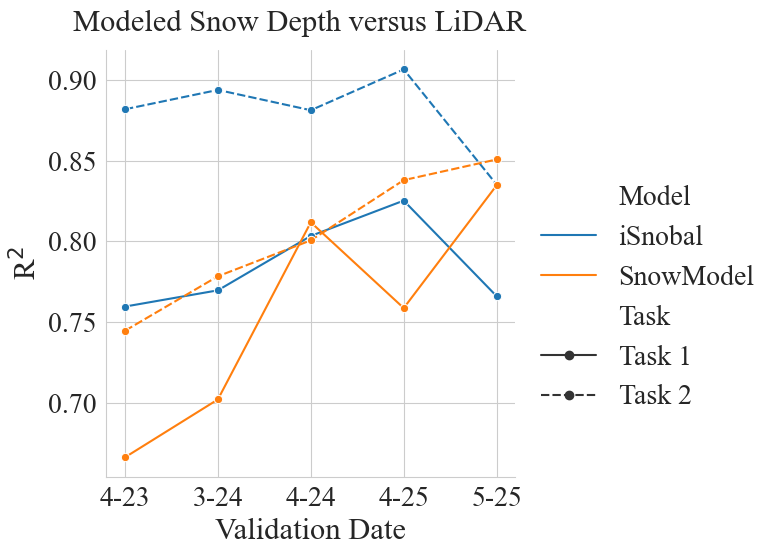

In [22]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

g = sns.relplot(
    data=df_filtered_isno,
    x='Date',
    y='r-squared',
    hue='Model',
    style='Task',
    kind='line',
    markers = 'o')
g.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
g.set_axis_labels("Validation Date", "R$^2$", fontsize=22)
g.tick_params(axis='both', which='major', labelsize=20)
g._legend.set_title("")

g.fig.suptitle(
    "Modeled Snow Depth versus LiDAR",
    fontsize=22,
    y=1.05,
    ha='center',
    x=0.45
)

sns.move_legend(
    g, "upper left", 
    bbox_to_anchor=(.8, .75), 
    title="",           
    fontsize=20,       
    title_fontsize=1    
)
plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/iSno_rsquared.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

C:\Users\RDCRLSMC\AppData\Local\Temp\2\ipykernel_9440\2964395488.py:4: UserWarning: 
The markers list has fewer values (1) than needed (2) and will cycle, which may produce an uninterpretable plot.
  g = sns.relplot(


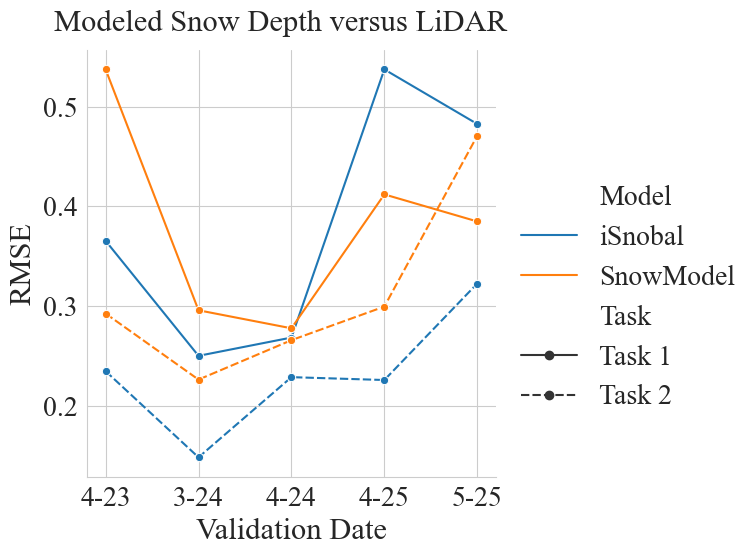

In [23]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

g = sns.relplot(
    data=df_filtered_isno,
    x='Date',
    y='RMSE',
    hue='Model',
    style='Task',
    kind='line',
    markers = 'o')
g.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
g.set_axis_labels("Validation Date", "RMSE", fontsize=22)
g.tick_params(axis='both', which='major', labelsize=20)
g._legend.set_title("")

g.fig.suptitle(
    "Modeled Snow Depth versus LiDAR",
    fontsize=22,
    y=1.05,
    ha='center',
    x=0.45
)

sns.move_legend(
    g, "upper left", 
    bbox_to_anchor=(.8, .75), 
    title="",           
    fontsize=20,       
    title_fontsize=1    
)
plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/iSno_RMSE.png",
    dpi=300,
    bbox_inches='tight'
)
plt.show()

In [25]:
# Assume 'lidar' is defined somewhere in your script as before

def create_regression_plot(YYYYMMDD, plot_title):
    """
    Generates and displays a 4-panel regression plot for snow depth models.

    Args:
        resample_data (dict): A dictionary where keys are model names and values 
                              are paths to the model's raster data.
        plot_date (str): The date string to be used as the main title for the figure.
    """
    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample = task1[date]['resample']

    # --- Loop through each model to create a subplot ---
    for i, (name, model_data_path) in enumerate(resample.items()):
        raster = rxr.open_rasterio(model_data_path, masked=True).squeeze()
        
        # 1. Flatten and clean data
        x = lidar.values.flatten()
        y = raster.values.flatten()
        mask = ~np.isnan(x) & ~np.isnan(y)
        x_clean = x[mask]
        y_clean = y[mask]

        ax = axs[i]
        
        # 2. Create the regression plot
        sns.regplot(x=x_clean, y=y_clean, ax=ax,
                    scatter_kws={'alpha': 0.8, 's': 10},
                    line_kws={'color': 'red'})
                    
        # 3. Calculate statistics
        slope, intercept, r_value, p_value, std_err = linregress(x_clean, y_clean)
        r_squared = r_value**2
        
        # 4. Add titles and labels
        ax.set_title(name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # 5. Add statistics text box
        stats_text = f'$R^2 = {r_squared:.3f}$\n$y = {slope:.2f}x + {intercept:.2f}$'
        ax.text(0.05, 0.95, stats_text, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='white', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



In [26]:
# from rasterio.plot import show
   
date = '20230405'
lidar = task1[date]['lidar']
lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
lidar = lidar.where(lidar < 5)
resample_task1 = task1[date]['resample']
resample_task2 = task2[date]['resample']
keys = list(resample_task1.keys())
    
model_name = 'iSnobal'
y1 = rxr.open_rasterio(resample_task1[model_name], masked=True).squeeze()
y2 = rxr.open_rasterio(resample_task2[model_name], masked=True).squeeze()
        
x = lidar.values.flatten()
y1_flat = y1.values.flatten()
y2_flat = y2.values.flatten()

nan_mask = ~np.isnan(x) & ~np.isnan(y1_flat) & ~np.isnan(y2_flat)

x_clean = x[nan_mask]
y1_clean = y1_flat[nan_mask]
y2_clean = y2_flat[nan_mask]

        # slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x, y1_flat)
print(linregress(x_clean, y1_clean))
#         # r_squared1 = r_value1**2
#         # print(slope1, intercept1, r_value1, p_value1, std_err1)
#         
#         # slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x, y2_flat)
print(linregress(x_clean, y2_clean))
        # r_squared2 = r_value2**2
        # print(slope2, intercept2, r_value2, p_value2, std_err2)

LinregressResult(slope=0.8824589632738516, intercept=0.08136186518493105, rvalue=0.8716070499041947, pvalue=0.0, stderr=0.00939782713524977, intercept_stderr=0.026011201202772605)
LinregressResult(slope=1.010370780021502, intercept=0.09219318023150347, rvalue=0.9390051402245881, pvalue=0.0, stderr=0.007006879517649436, intercept_stderr=0.019393563034751628)


In [27]:
def regression_plot_compare(YYYYMMDD, plot_title):

    sns.set_style('whitegrid')
    fig, axs = plt.subplots(nrows=1, ncols=4, figsize=(22, 5), sharey=True)
    fig.suptitle(plot_title, fontsize=18, fontweight='bold')
    
    # --- select data
    date = YYYYMMDD
    lidar = task1[date]['lidar']
    lidar = rxr.open_rasterio(lidar, masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    resample_task1 = task1[date]['resample']
    resample_task2 = task2[date]['resample']
    keys = list(resample_task1.keys())
    
    for idx in range(len(resample_task1)):
        ax = axs[idx]
        model_name = keys[idx]
        y1 = rxr.open_rasterio(resample_task1[model_name], masked=True).squeeze()
        y2 = rxr.open_rasterio(resample_task2[model_name], masked=True).squeeze()
        
        x = lidar.values.flatten()
        y1_flat = y1.values.flatten()
        y2_flat = y2.values.flatten()
        
        nan_mask = ~np.isnan(x) & ~np.isnan(y1_flat) & ~np.isnan(y2_flat)

        x_clean = x[nan_mask]
        y1_clean = y1_flat[nan_mask]
        y2_clean = y2_flat[nan_mask]

        sns.regplot(x=x, y=y1_flat, fit_reg=False, ax=axs[idx]) #scatter_kws={'alpha': 0.8, 's': 10})
        sns.regplot(x=x, y=y2_flat, fit_reg=False, ax=axs[idx]) #scatter_kws={'alpha': 0.8, 's': 10})
        start = [0,0]
        end = [4,4]
        ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')

        # # 3. Calculate statistics
        slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_clean, y1_clean)
        r_squared1 = r_value1**2
        
        slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x_clean, y2_clean)
        r_squared2 = r_value2**2
        
        # 4. Add titles and labels
        ax.set_title(model_name, fontsize=14, fontweight='bold')
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

        # # 5. Add statistics text box
        stats_text1 = f'$R^2 = {r_squared1:.3f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
        ax.text(0.05, 0.95, stats_text1, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
        
        stats_text2 = f'$R^2 = {r_squared2:.3f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
        ax.text(0.35, 0.95, stats_text2, 
                transform=ax.transAxes, 
                fontsize=11, 
                verticalalignment='top',
                bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

    # --- Final Figure-Level Adjustments ---
    axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
    plt.tight_layout()
    
    # Display the final plot
    plt.show()



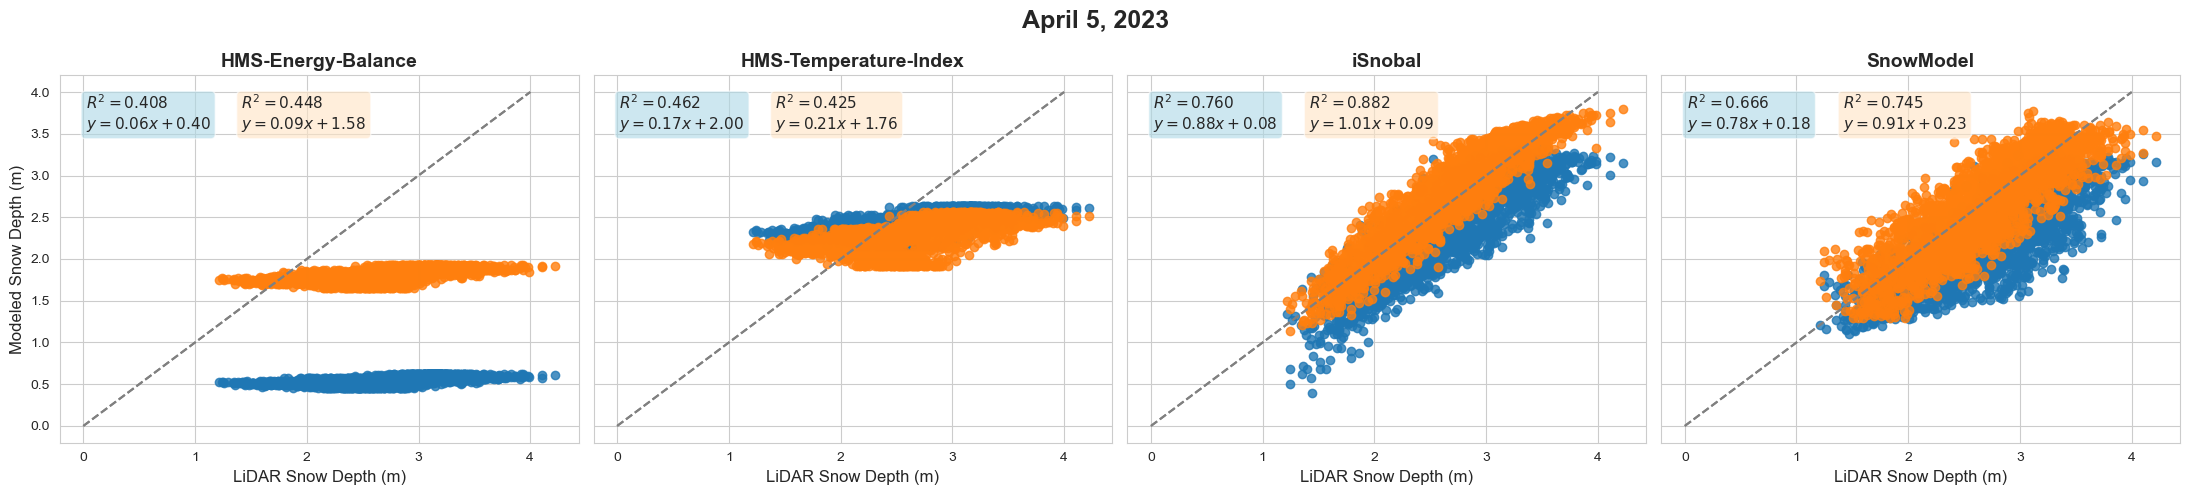

In [28]:
regression_plot_compare('20230405', "April 5, 2023")
# regression_plot_compare('20240315', "March 15, 2024")
# regression_plot_compare('20240418', "April 18, 2024")
# regression_plot_compare('20250404', "April 4, 2025")
# regression_plot_compare('20250501', "May 1, 2025")

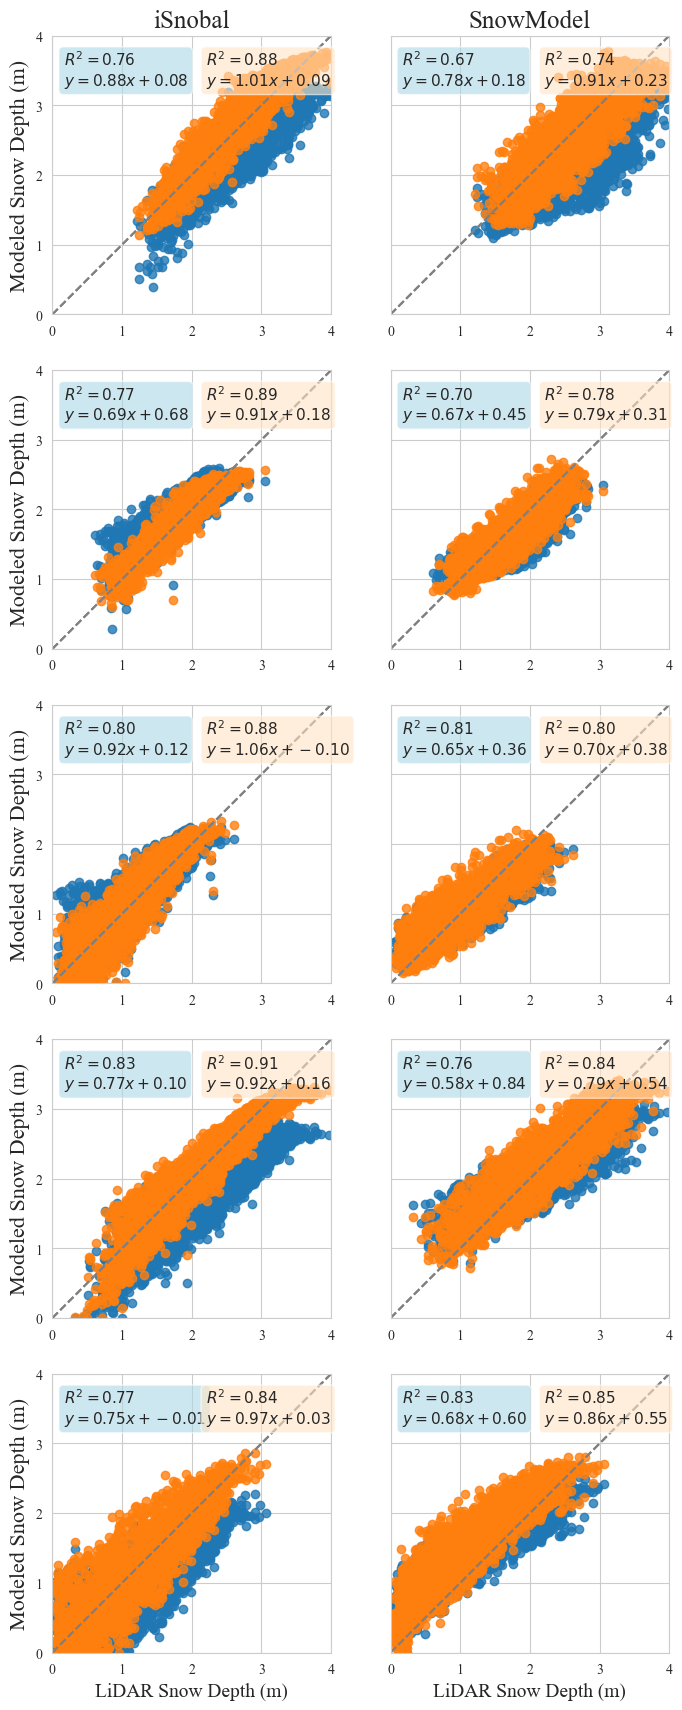

In [29]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

dates = ['April 5, 2023', 'March 15, 2024', 'April 18, 2024', 'April 4, 2025', 'May 1, 2025']

sns.set_style('whitegrid')
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']
fig, axs = plt.subplots(
    nrows=5, ncols=2,
    figsize=(8,21),
    sharey=True
)
fig.suptitle("", fontsize=18, fontweight='bold')
cols = ['iSnobal', 'SnowModel']
for ax, col in zip(axs[0], cols):
    ax.set_title(col, fontsize = 18)
    
resample_task1 = []
resample_task2 = []
lidar_list = []

for key in task1.keys():
    date = key
    lidar = task1[date]['lidar']
    lidar_list.append(lidar)
    resample_task1.append({
        "iSnobal" : task1[date]['resample']['iSnobal'], 
        "SnowModel" : task1[date]['resample']['SnowModel']})
    
    resample_task2.append({
        "iSnobal" : task2[date]['resample']['iSnobal'], 
        "SnowModel" : task2[date]['resample']['SnowModel']})
    

for idx in range(len(resample_task1)):

    # Load LiDAR
    lidar = rxr.open_rasterio(lidar_list[idx], masked=True).squeeze()
    lidar = lidar.where(lidar < 5)
    x = lidar.values.flatten()

    ax = axs[idx,0]   
    y1 = rxr.open_rasterio(resample_task1[idx]['iSnobal'], masked=True).squeeze()
    y2 = rxr.open_rasterio(resample_task2[idx]['iSnobal'], masked=True).squeeze()
    y1 = y1.values.flatten()
    y2 = y2.values.flatten()

    mask = ~np.isnan(x) & ~np.isnan(y1) & ~np.isnan(y2)

    sns.regplot(x=x[mask], y=y1[mask], fit_reg=False, ax=ax)
    sns.regplot(x=x[mask], y=y2[mask], fit_reg=False, ax=ax)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_aspect('equal', adjustable='box')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    ax.set_ylabel("Modeled Snow Depth (m)", fontsize=16)
    ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=16)
    start = [0,0]
    end = [4,4]
    if idx == 4:
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=14)
    else:
        ax.set_xlabel("", fontsize=12)
    
    ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')
    # # 3. Calculate statistics
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x[mask], y1[mask])
    r_squared1 = r_value1**2
    
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x[mask], y2[mask])
    r_squared2 = r_value2**2

    # # 5. Add statistics text box
    stats_text1 = f'$R^2 = {r_squared1:.2f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
    ax.text(0.04, 0.95, stats_text1, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
    
    stats_text2 = f'$R^2 = {r_squared2:.2f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
    ax.text(0.55, 0.95, stats_text2, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

#######################################################
    # SnowModel (col 1)
    ax = axs[idx,1]  

    y1 = rxr.open_rasterio(resample_task1[idx]['SnowModel'], masked=True).squeeze()
    y2 = rxr.open_rasterio(resample_task2[idx]['SnowModel'], masked=True).squeeze()

    y1 = y1.values.flatten()
    y2 = y2.values.flatten()

    mask = ~np.isnan(x) & ~np.isnan(y1) & ~np.isnan(y2)

    sns.regplot(x=x[mask], y=y1[mask], fit_reg=False, ax=ax)
    sns.regplot(x=x[mask], y=y2[mask], fit_reg=False, ax=ax)
    ax.set_xlim(0, 4)
    ax.set_ylim(0, 4)
    ax.set_aspect('equal', adjustable='box')
    ax.xaxis.set_major_locator(MaxNLocator(integer=True))
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    
    if idx == 4:
        ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=14)
    else:
        ax.set_xlabel("", fontsize=12)
    start = [0,0]
    end = [4,4]
    ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')
    # # 3. Calculate statistics
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x[mask], y1[mask])
    r_squared1 = r_value1**2
    
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x[mask], y2[mask])
    r_squared2 = r_value2**2

    # # 5. Add statistics text box
    stats_text1 = f'$R^2 = {r_squared1:.2f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
    ax.text(0.04, 0.95, stats_text1, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
    
    stats_text2 = f'$R^2 = {r_squared2:.2f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
    ax.text(0.55, 0.95, stats_text2, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))


plt.savefig(
    "C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/regressions.png",
    dpi=300,
    bbox_inches='tight'
)
#plt.tight_layout()
plt.show()

In [30]:
diff_list = []
for date in task1.keys():
    diff_task1 = task1[date]['diff']
    diff_task2 = task2[date]['diff']
    diff_list.append(list(diff_task1.values()) + list(diff_task2.values()))

#print(diff_list)
for date in diff_list:
    for filepath in date:
        path = Path(filepath)
        if path.exists():
            print(path)
        else:
            print('File not found--------------------------------------------\n{filepath}\n')

C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task1\rasters\HMS_Energy_Balance_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task1\rasters\HMS_Temperature_Index_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task1\rasters\iSnobal_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task1\rasters\SnowModel_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task2\rasters\HMS_Energy_Balance_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task2\rasters\HMS_Temperature_Index_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task2\rasters\iSnobal_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20230405\outputs\task2\rasters\SnowModel_lidar_diff.tif
C:\Users\RDCRLSMC\Desktop\SIRO\Model_Outputs\dates\20240315\outputs\task1\rasters\HMS_Energy_Balance_lidar

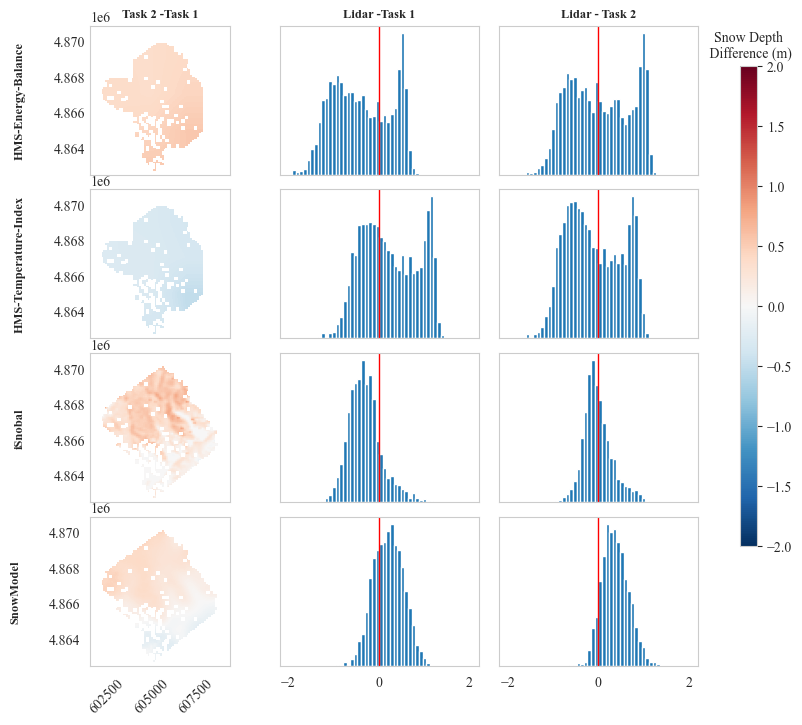

In [32]:

fig, axs = plt.subplots(nrows=4, ncols=3, figsize=(8.5, 8))#, sharex='col')
#fig.suptitle(f'Task 1 & 2 Comparison, {date}', fontsize=16)
vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

for i, (model_name, task1_path) in enumerate(diff_task1.items()):
    task2_path = diff_task2[model_name]

    # --- Process and Plot Task 1 ---
    with rasterio.open(task1_path) as src:
        task1_data = src.read(1)
        nodata_val = src.nodata
        bounds = src.bounds
    with rasterio.open(task2_path) as src:
        task2_data = src.read(1)
        nodata_val = src.nodata
        data = task2_data - task1_data

    # Plot the raster image in the first column
    ax_img1 = axs[i, 0]
    im = ax_img1.imshow(data, cmap=colormap,norm=normalize, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax_img1.grid(False)
    ax_img1.set_ylabel(model_name, fontsize=9, va="bottom", labelpad=20, fontweight='bold')

    if i  != 3:
        ax_img1.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=True, right=False, labelbottom=False, labelleft=True, length=0)
    else:
        ax_img1.tick_params(axis='x', labelrotation=45)
    
    # Plot the histogram in the second column
    ax_hist1 = axs[i, 1]
    ax_hist1.grid(False)
    task1_flat = task1_data[task1_data != nodata_val].flatten() if nodata_val is not None else task1_data.flatten()
    ax_hist1.hist(task1_flat, bins=50,range=(-2,2))
    ax_hist1.axvline(0, color='red', linestyle='-', linewidth=1)
    if i  != 3:
        ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=False, right=False, labelbottom=False, labelleft=False)
    else:
        ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=False, right=False, labelbottom=True, labelleft=False)

    
    # Plot the histogram in the fourth column
    ax_hist2 = axs[i, 2]
    ax_hist2.grid(False)
    task2_flat = task2_data[task2_data != nodata_val].flatten() if nodata_val is not None else task2_data.flatten()
    ax_hist2.hist(task2_flat, bins=50, range=(-2,2))
    ax_hist2.axvline(0, color='red', linestyle='-', linewidth=1)
    
    if i  != 3:
        ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=False, right=False, labelbottom=False, labelleft=False)
    else:
        ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=False, right=False, labelbottom=True, labelleft=False)

ax_img1 = axs[0,0]
ax_hist1 = axs[0, 1]
ax_hist2 = axs[0, 2]
ax_img1.set_title('Task 2 -Task 1', fontsize=9, fontweight='bold')
ax_hist1.set_title('Lidar -Task 1', fontsize=9, fontweight='bold')
ax_hist2.set_title('Lidar - Task 2', fontsize=9, fontweight='bold')

plt.subplots_adjust(left=0.1, right=0.85, bottom=0.1, top=0.9, wspace=0.1, hspace=0.1)
cbar_ax = fig.add_axes([0.9, 0.25, 0.02, 0.6]) # [left, bottom, width, height]

# Add the colorbar to the *newly created* axes (cbar_ax)
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=10)
# Adjust layout to prevent titles and labels from overlapping
# Display the plot
plt.show()


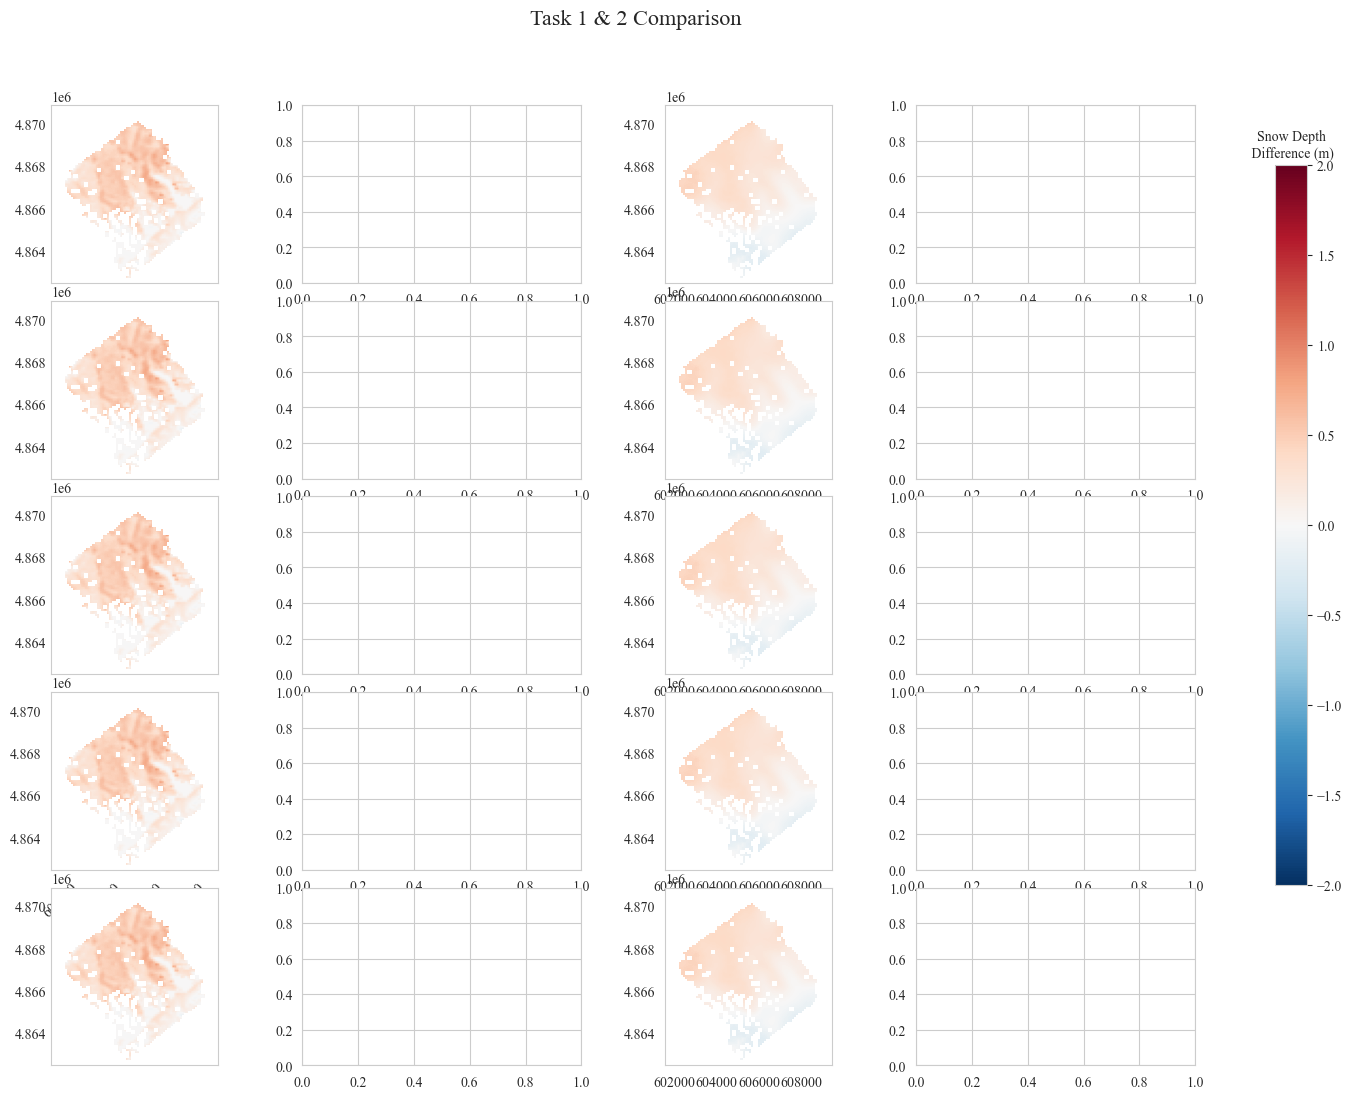

In [33]:

fig, axs = plt.subplots(nrows=5, ncols=4, figsize = (16,12))#, sharex='col')
fig.suptitle(f'iSnobal and SnowModel Comparison', fontsize=16)
vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r


for i, (keys) in enumerate(task1.keys()):
    m1 = task1[key]['resample']['iSnobal']
    m2 = task1[key]['resample']['SnowModel']

    # --- Process and Plot Task 1 ---
    with rasterio.open(m1) as src:
        task1_data = src.read(1)
        nodata_val = src.nodata
        bounds = src.bounds
    with rasterio.open(m2) as src:
        task2_data = src.read(1)
        nodata_val = src.nodata
        data = task2_data - task1_data
    
    

    # Plot the raster image in the first column
    ax_img1 = axs[i, 0]
    im = ax_img1.imshow(data, cmap=colormap,norm=normalize, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax_img1.grid(False)
    #ax_img1.set_ylabel(model_name, fontsize=9, va="bottom", labelpad=20, fontweight='bold')

    if i  != 3:
        ax_img1.tick_params(axis='both', which='both', bottom=False, top=False, 
                          left=True, right=False, labelbottom=False, labelleft=True, length=0)
    else:
        ax_img1.tick_params(axis='x', labelrotation=45)
    
    # # Plot the histogram in the second column
    # ax_hist1 = axs[i, 1]
    # ax_hist1.grid(False)
    # task1_flat = task1_data[task1_data != nodata_val].flatten() if nodata_val is not None else task1_data.flatten()
    # ax_hist1.hist(task1_flat, bins=50,range=(-2,2))
    # ax_hist1.axvline(0, color='red', linestyle='-', linewidth=1)
    # if i  != 3:
    #     ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
    #                       left=False, right=False, labelbottom=False, labelleft=False)
    # else:
    #     ax_hist1.tick_params(axis='both', which='both', bottom=False, top=False, 
    #                       left=False, right=False, labelbottom=True, labelleft=False)
    # 
    # 
    ##################################################################################
    m1 = task1[key]['resample']['SnowModel']
    m2 = task2[key]['resample']['SnowModel']

    # --- Process and Plot Task 1 ---
    with rasterio.open(m1) as src:
        task1_data = src.read(1)
        nodata_val = src.nodata
        bounds = src.bounds
    with rasterio.open(m2) as src:
        task2_data = src.read(1)
        nodata_val = src.nodata
        data = task2_data - task1_data

    # Plot the raster image in the first column
    ax_img1 = axs[i, 2]
    im = ax_img1.imshow(data, cmap=colormap,norm=normalize, extent=[bounds.left, bounds.right, bounds.bottom, bounds.top])
    ax_img1.grid(False)
    #ax_img1.set_ylabel(model_name, fontsize=9, va="bottom", labelpad=20, fontweight='bold')
    
    
    # # Plot the histogram in the fourth column
    # ax_hist2 = axs[i, 3]
    # ax_hist2.grid(False)
    # task2_flat = task2_data[task2_data != nodata_val].flatten() if nodata_val is not None else task2_data.flatten()
    # ax_hist2.hist(task2_flat, bins=50, range=(-2,2))
    # ax_hist2.axvline(0, color='red', linestyle='-', linewidth=1)
    # 
    # if i  != 3:
    #     ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
    #                       left=False, right=False, labelbottom=False, labelleft=False)
    # else:
    #     ax_hist2.tick_params(axis='both', which='both', bottom=False, top=False, 
    #                       left=False, right=False, labelbottom=True, labelleft=False)

# ax_img1 = axs[0,0]
# ax_hist1 = axs[0, 1]
# ax_hist2 = axs[0, 2]
# ax_img1.set_title('Task 2 -Task 1', fontsize=9, fontweight='bold')
# ax_hist1.set_title('Lidar -Task 1', fontsize=9, fontweight='bold')
# ax_hist2.set_title('Lidar - Task 2', fontsize=9, fontweight='bold')

plt.subplots_adjust(left=0.1, right=0.85, bottom=0.1, top=0.9, wspace=0.1, hspace=0.1)
cbar_ax = fig.add_axes([0.9, 0.25, 0.02, 0.6]) # [left, bottom, width, height]

# Add the colorbar to the *newly created* axes (cbar_ax)
cbar = fig.colorbar(im, cax=cbar_ax, orientation='vertical')
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=10)
# Adjust layout to prevent titles and labels from overlapping
# Display the plot
plt.show()


In [34]:
date = '20230405'

basin_task1 = task1[date]['basin_clip']
basin_task2 = task2[date]['basin_clip']
HMSEB = basin_task1['HMS-EB']
HMSTI = basin_task1['HMS-TI']
iSnobal = basin_task1['iSnobal']
SnowModel = basin_task1['SnowModel']

raster_list = {'HMS-EB': HMSEB, 'SnowModel': SnowModel, 'iSnobal': iSnobal}

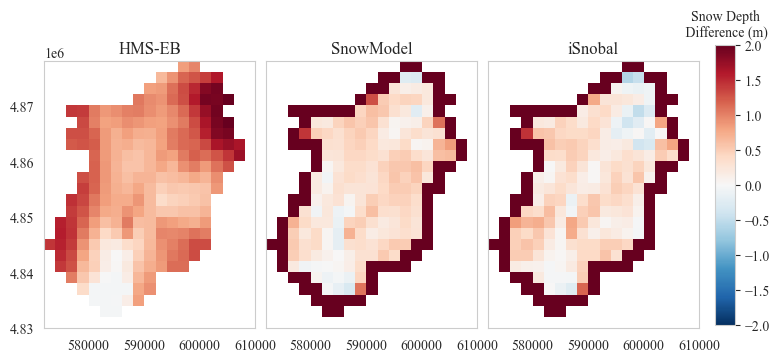

In [35]:
vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

fig, axs = plt.subplots(nrows=1, ncols=3, figsize=(8, 4), sharex=True, sharey=True)#, sharex='col')

with rasterio.open(HMSTI) as ref:
    TI = ref.read(1, masked=True)
    profile = ref.profile
    extent = [ref.bounds.left, ref.bounds.right, ref.bounds.bottom, ref.bounds.top]
    
    for i, (model, data) in enumerate(raster_list.items()):
        with rasterio.open(data) as src:
            reprojected_data = np.empty_like(TI)
            
            reproject(
                source=src.read(1),  # <-- CORRECTED: Use the source data
                destination=reprojected_data,
                src_transform=src.transform,
                src_crs='EPSG:32611',
                dst_transform=profile['transform'],
                dst_crs='EPSG:32611',
                resampling=Resampling.bilinear
            )
            reprojected_data = np.ma.masked_equal(reprojected_data, ref.nodata)
            diff = TI - reprojected_data 
        
            im = axs[i].imshow(diff, cmap=colormap, norm = normalize, extent=extent)
            
            axs[i].set_title(model)
            axs[i].grid(False)
            
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space
# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.9, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=10)

fig.suptitle("", fontsize=16,  y=0.95)

fig.subplots_adjust(
    wspace=0.05,
    hspace=0.06,
    right=0.88
    #top=0.90
)

plt.show() 


In [36]:
date = '20230405'

basin_task1 = task1[date]['basin_clip']
basin_task2 = task2[date]['basin_clip']
HMSEB = basin_task1['HMS-EB']
HMSTI = basin_task1['HMS-TI']
iSnobal = basin_task1['iSnobal']
SnowModel = basin_task1['SnowModel']

raster_list = {'HMS-EB': HMSEB,'HMS-TI':HMSTI, 'SnowModel': SnowModel, 'iSnobal': iSnobal}

0.0 0.0
-0.044179596 2.0093822
-0.043602604 1.9787986
-0.03774932 2.2327535
-2.0093822 0.044179596
0.0 0.0
-0.8406861 0.47802413
-0.83763397 0.5835079
-2.7434263 0.112229966
-1.0256498 1.24647
0.0 0.0
-1.7754455 0.8937589
-2.7633555 0.4709351
-1.2773719 2.2122138
-0.8796123 1.9359812
0.0 0.0


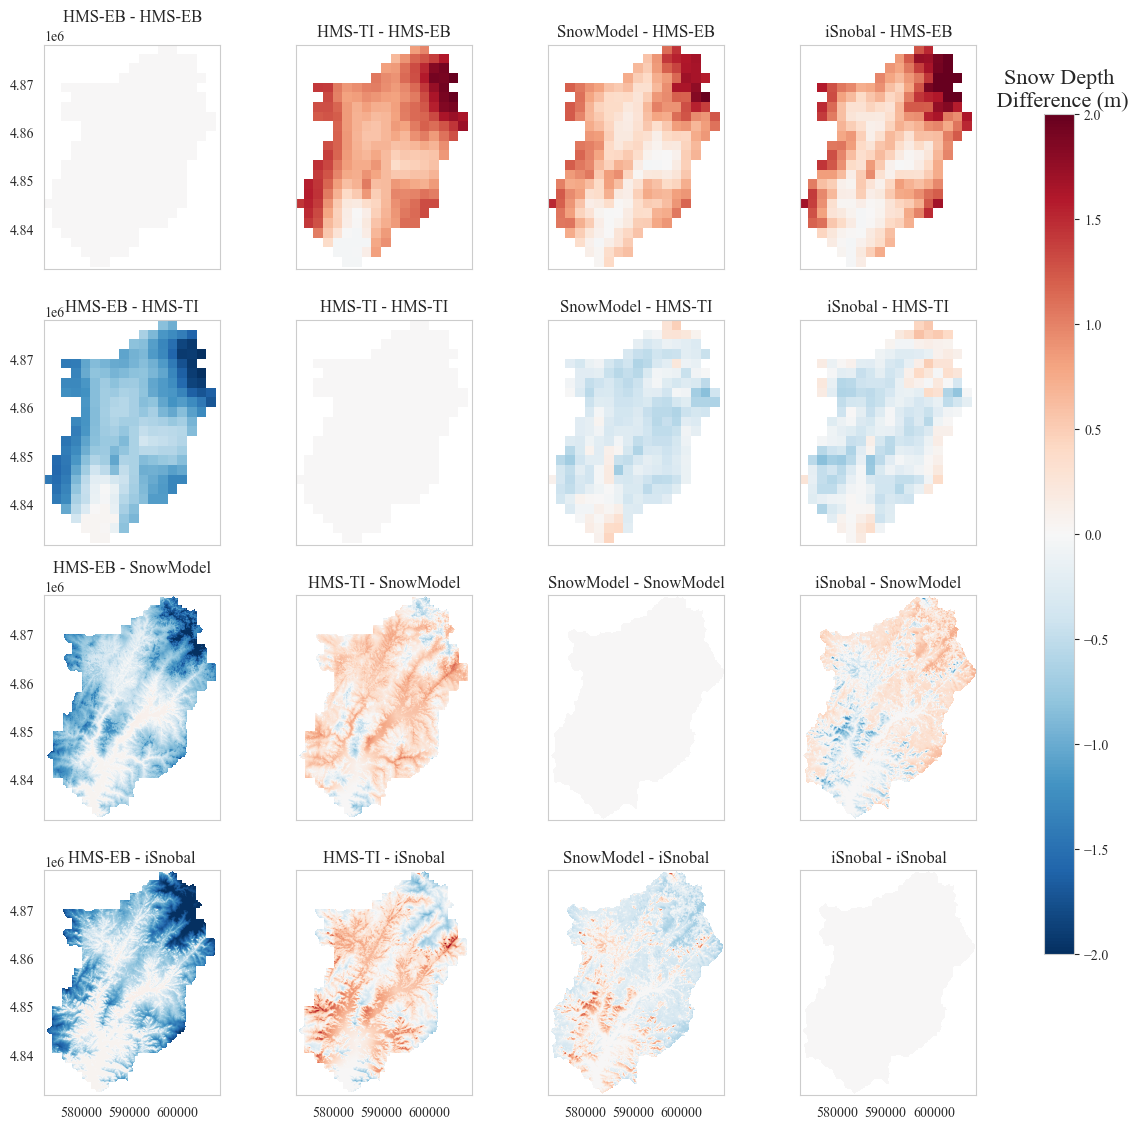

In [37]:
vcenter = 0.0
vmin = -2
vmax = 2
normalize = mcolors.TwoSlopeNorm(vmin=vmin, vcenter=vcenter, vmax=vmax)
colormap = cm.RdBu_r

fig, axs = plt.subplots(nrows=4, ncols=4, figsize=(12, 12),
                        sharex=True, sharey=True)

for i, (row_model, row_path) in enumerate(raster_list.items()):
    
    with rasterio.open(row_path) as ref:
        row_data = ref.read(1, masked=True)
        ref_transform = ref.transform
        ref_crs = ref.crs
        ref_nodata = ref.nodata
        extent = [ref.bounds.left, ref.bounds.right,
                  ref.bounds.bottom, ref.bounds.top]

        for j, (col_model, col_path) in enumerate(raster_list.items()):
            
            with rasterio.open(col_path) as src:
                src_data = src.read(1)
                
                # Allocate destination array
                dst = np.empty_like(row_data, dtype=np.float32)

                reproject(
                    source=src_data,
                    destination=dst,
                    src_transform=src.transform,
                    src_crs='EPSG:32611',
                    src_nodata=-9999,
                    dst_transform=ref_transform,
                    dst_crs='EPSG:32611',
                    dst_nodata=-9999,
                    resampling=Resampling.bilinear
                )

                # Mask nodata
                dst = np.ma.masked_equal(dst, -9999)
                
                # Column minus row
                diff = dst - row_data
                
                print(diff.min(), diff.max())

                ax = axs[i, j]
                im = ax.imshow(diff,
                               cmap=colormap,
                               norm=normalize,
                               extent=extent)
                ax.set_title(f"{col_model} - {row_model}")
                ax.grid(False)
                
fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space
# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.9, 0.15, 0.025, 0.7])
cbar = fig.colorbar(im, cax=cbar_ax)
cbar.ax.set_title('Snow Depth\n Difference (m)', fontsize=16)

plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/basin_compare.png", dpi=600)


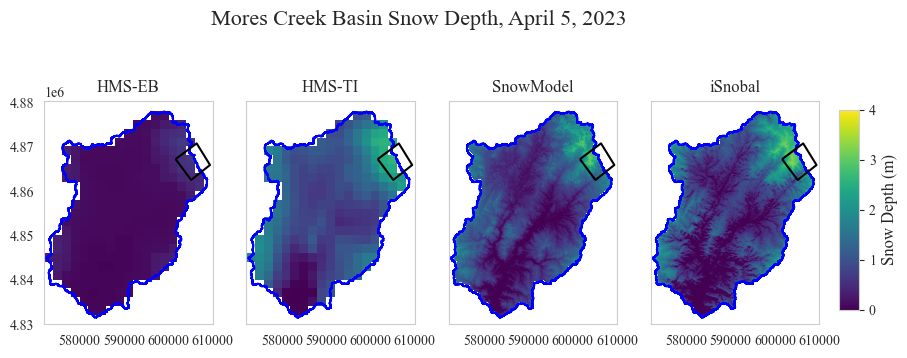

In [38]:
mcs_shp = gpd.read_file("C:/Users/RDCRLSMC/Desktop/GIS/MCS/MCS_shp/MCS_outline.shp")
basin_shp = gpd.read_file("C:/Users/RDCRLSMC/Desktop/GIS/basin/basin_outline.shp")

fig, axes = plt.subplots(1, 4, figsize=(10, 5), sharex=True, sharey=True)
axes = axes.flatten()  # flatten to 1D array for easy looping

for i, (model, raster) in enumerate(raster_list.items()):

    with rasterio.open(raster) as src:
        data = src.read(1, masked=True)  # read first band, mask NoData
        extent = [src.bounds.left, src.bounds.right, src.bounds.bottom, src.bounds.top]
    
    im = axes[i].imshow(data, cmap="viridis",
                        extent=extent,
                        vmin=0,vmax=4.0 )
    axes[i].set_title(model)
    axes[i].grid(False)
    basin_shp.plot(ax=axes[i], facecolor='none', edgecolor='blue', linewidth=1.5)

    mcs_shp.plot(ax=axes[i], facecolor='none', edgecolor='black', linewidth=1.5)


# Add colorbar

#fig.colorbar(im, ax=axes, orientation="vertical", fraction=0.02, extend="max", label="Snow Depth")

# --- 5. Add a single, shared colorbar ---
#fig.tight_layout(rect=[0, 0, 0.9, 0.95]) # Adjust layout to make space

# Add axes for the colorbar [left, bottom, width, height]
cbar_ax = fig.add_axes([0.92, 0.3, 0.02, 0.4])
#cbar_ax = fig.add_axes([0.25, 0.15, 0.5, 0.03]) 

cbar = fig.colorbar(im, cax=cbar_ax)#, orientation='horizontal')
cbar.set_label('Snow Depth (m)', fontsize=12)

fig.suptitle(f"Mores Creek Basin Snow Depth, April 5, 2023", fontsize=16,  y=0.90)

# fig.subplots_adjust(
#     wspace=0.05,
#     hspace=0.0,
#     right=0.88
#     #top=0.90
# )

plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/fulls_models_onerow_v2.png", dpi=600)
plt.show()

## I need to resample LIDAR data to match HMS, rather than HMS to match LiDAR. I then need to repeat my regressions.

In [14]:
def HMS_dates(dir):
    dictionary = {"20230405": glob.glob(os.path.join(dir,'*2023_04_05*')),
                       "20240315": glob.glob(os.path.join(dir, '*2024_03_15*')),
                       "20240418": glob.glob(os.path.join(dir, '*2024_04_18*')) + glob.glob(os.path.join(dir, '*2024_04_15*')),
                       "20250404": glob.glob(os.path.join(dir, '*2025_04_04*')),
                       "20250501": glob.glob(os.path.join(dir, '*2025_05_01*')),}

    return dictionary

In [15]:
EB_t1 = HMS_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task1/2026.01.16_HMS_results/EB/snow_depth")
TI_t1 = HMS_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task1/2026.01.16_HMS_results/TI/snowdepth")

EB_t2 = HMS_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task2/HMS_Task2/WY2023-2025_EB_HRRR_2000m")
TI_t2 = HMS_dates("C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task2/HMS_Task2/WY2023-2025_TI_HRRR_2000m")

In [16]:
for date in task1.keys():
    lidar = task1[date]['lidar']
    print(lidar)


C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\20230405\outputs/task1/rasters\LiDAR_MCS_clip.tif
C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\20240315\outputs/task1/rasters\LiDAR_MCS_clip.tif
C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\20240418\outputs/task1/rasters\LiDAR_MCS_clip.tif
C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\20250404\outputs/task1/rasters\LiDAR_MCS_clip.tif
C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/dates\20250501\outputs/task1/rasters\LiDAR_MCS_clip.tif


In [18]:
model, raster_list = list(TI_t1.items())[0]
raster_path = raster_list[0] 
print(raster_path)

out_dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task1/lidar_HMS"
ref = rxr.open_rasterio(raster_path)

for date in task1.keys():
    lidar = task1[date]['lidar']
    source = rxr.open_rasterio(lidar)
    reprojected_raster = source.rio.reproject_match(ref)
    reprojected_raster.rio.to_raster(os.path.join(out_dir, f"{date}_reprojected.tif"), driver='GTiff')   

IndexError: list index out of range

In [10]:
lidar_dir = "C:/Users/RDCRLSMC/Desktop/SIRO/Model_Outputs/Task1/lidar_HMS"

lidar_dict = {"20230405": glob.glob(os.path.join(lidar_dir,'*20230405*')),
                       "20240315": glob.glob(os.path.join(lidar_dir, '*20240315*')),
                       "20240418": glob.glob(os.path.join(lidar_dir, '*20240418*')) + glob.glob(os.path.join(lidar_dir, '*2024_04_15*')),
                       "20250404": glob.glob(os.path.join(lidar_dir, '*20250404*')),
                       "20250501": glob.glob(os.path.join(lidar_dir, '*20250501*')),}

lidar_dict

{'20230405': [],
 '20240315': [],
 '20240418': [],
 '20250404': [],
 '20250501': []}

IndexError: list index out of range

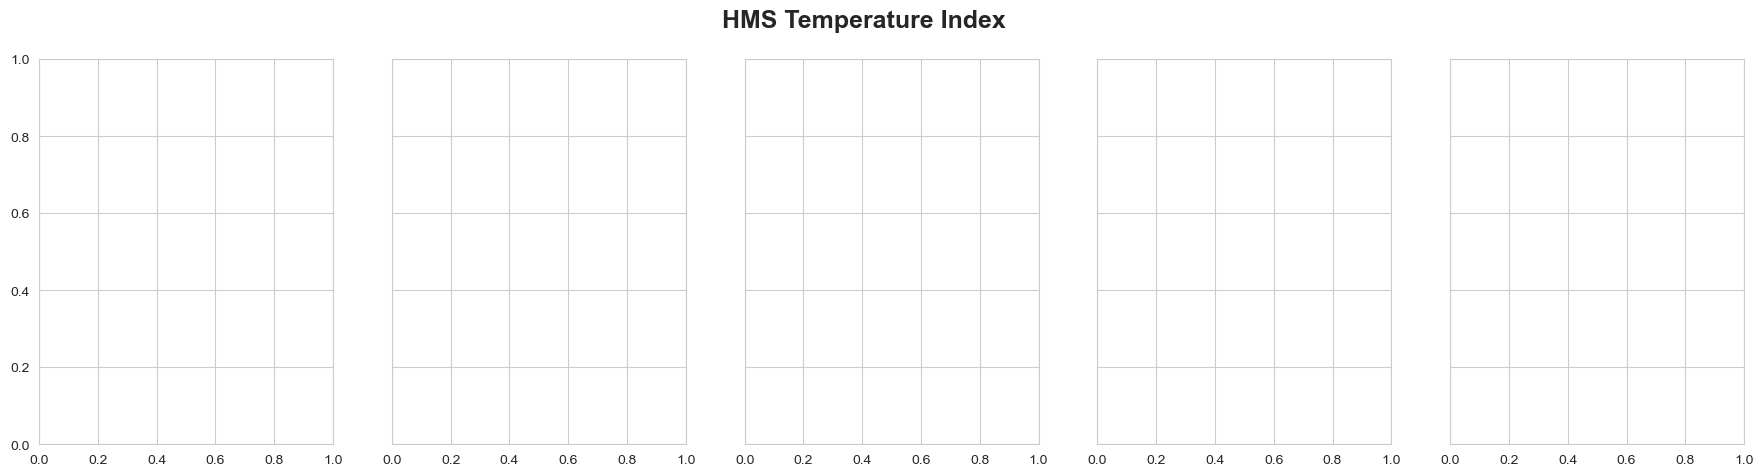

In [11]:
sns.set_style('whitegrid')
fig, axs = plt.subplots(nrows=1, ncols=5, figsize=(22, 5), sharey=True)
fig.suptitle("HMS Temperature Index", fontsize=18, fontweight='bold')
date_keys = list(lidar_dict.keys())

# --- select data

for idx, date in enumerate(date_keys):

    lidar_path = lidar_dict[date][0]
    t1_path = TI_t1[date][0]
    t2_path = TI_t2[date][0]
    
    lidar = rxr.open_rasterio(lidar_path, masked=True).squeeze()
    y1 = rxr.open_rasterio(t1_path, masked=True).squeeze()
    y2 = rxr.open_rasterio(t2_path, masked=True).squeeze()
    
    x_flat = lidar.values.flatten()
    y1_flat = y1.values.flatten()
    y2_flat = y2.values.flatten()
        
    y1_m = y1_flat * 0.0254 # Assuming original is inches
    y2_m = y2_flat * 0.0254
        
    nan_mask = ~np.isnan(x_flat) & ~np.isnan(y1_m) & ~np.isnan(y2_m)

    x_clean = x_flat[nan_mask]
    y1_clean = y1_m[nan_mask]
    y2_clean = y2_m[nan_mask]

    ax = axs[idx]    
    sns.regplot(x=x_clean, y=y1_clean, fit_reg=False, ax=ax) #scatter_kws={'alpha': 0.8, 's': 10})
    sns.regplot(x=x_clean, y=y2_clean, fit_reg=False, ax=ax) #scatter_kws={'alpha': 0.8, 's': 10})
    start = [0,0]
    end = [3,3]
    ax.plot([start, end], [start, end], color='gray', linestyle='--', label='1-to-1 Line (y=x)')

    # # 3. Calculate statistics
    slope1, intercept1, r_value1, p_value1, std_err1 = linregress(x_clean, y1_clean)
    r_squared1 = r_value1**2
    
    slope2, intercept2, r_value2, p_value2, std_err2 = linregress(x_clean, y2_clean)
    r_squared2 = r_value2**2
    
    # 4. Add titles and labels
    ax.set_title(date, fontsize=14, fontweight='bold')
    ax.set_xlabel("LiDAR Snow Depth (m)", fontsize=12)

    # # 5. Add statistics text box
    stats_text1 = f'$R^2 = {r_squared1:.3f}$\n$y = {slope1:.2f}x + {intercept1:.2f}$'
    ax.text(0.05, 0.95, stats_text1, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='lightblue', alpha=0.6))
    
    stats_text2 = f'$R^2 = {r_squared2:.3f}$\n$y = {slope2:.2f}x + {intercept2:.2f}$'
    ax.text(0.35, 0.95, stats_text2, 
            transform=ax.transAxes, 
            fontsize=11, 
            verticalalignment='top',
            bbox=dict(boxstyle='round,pad=0.3', fc='bisque', alpha=0.6))

# --- Final Figure-Level Adjustments ---
axs[0].set_ylabel("Modeled Snow Depth (m)", fontsize=12)
plt.tight_layout()

# Display the final plot
plt.show()



### Create boxplots that show spread off ALL dates combined

In [231]:
dfs = []

for key in task1.keys():
    task1_clip = task1[key]['basin_clip']
    task2_clip = task2[key]['basin_clip']
    
    MCS = {"Task 1":task1_clip, "Task 2":task2_clip}
    
    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    data = src.read(1)
                    mask = (data == -9999)
                    data_masked = np.ma.array(data, mask=mask)
                    flattened = data_masked.compressed()
                    flattened = flattened[flattened < 5]
                    
                    
                    df = pd.DataFrame({
                    "Task":task,
                    "Date":key,
                    "Model": name,        # this column will store model names
                    "Snow Depth": flattened,
                    "measured": name == "lidar"# this column stores raster values
                    })
                    dfs.append(df)
                
    
basin_domain = pd.concat(dfs, ignore_index=True)    

In [225]:
Task1_basin = basin_domain[basin_domain['Task'] =='Task 1']
Task2_basin = basin_domain[basin_domain['Task'] =='Task 2']

C:\Users\RDCRLSMC\AppData\Local\Temp\1\ipykernel_16228\3064228404.py:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])


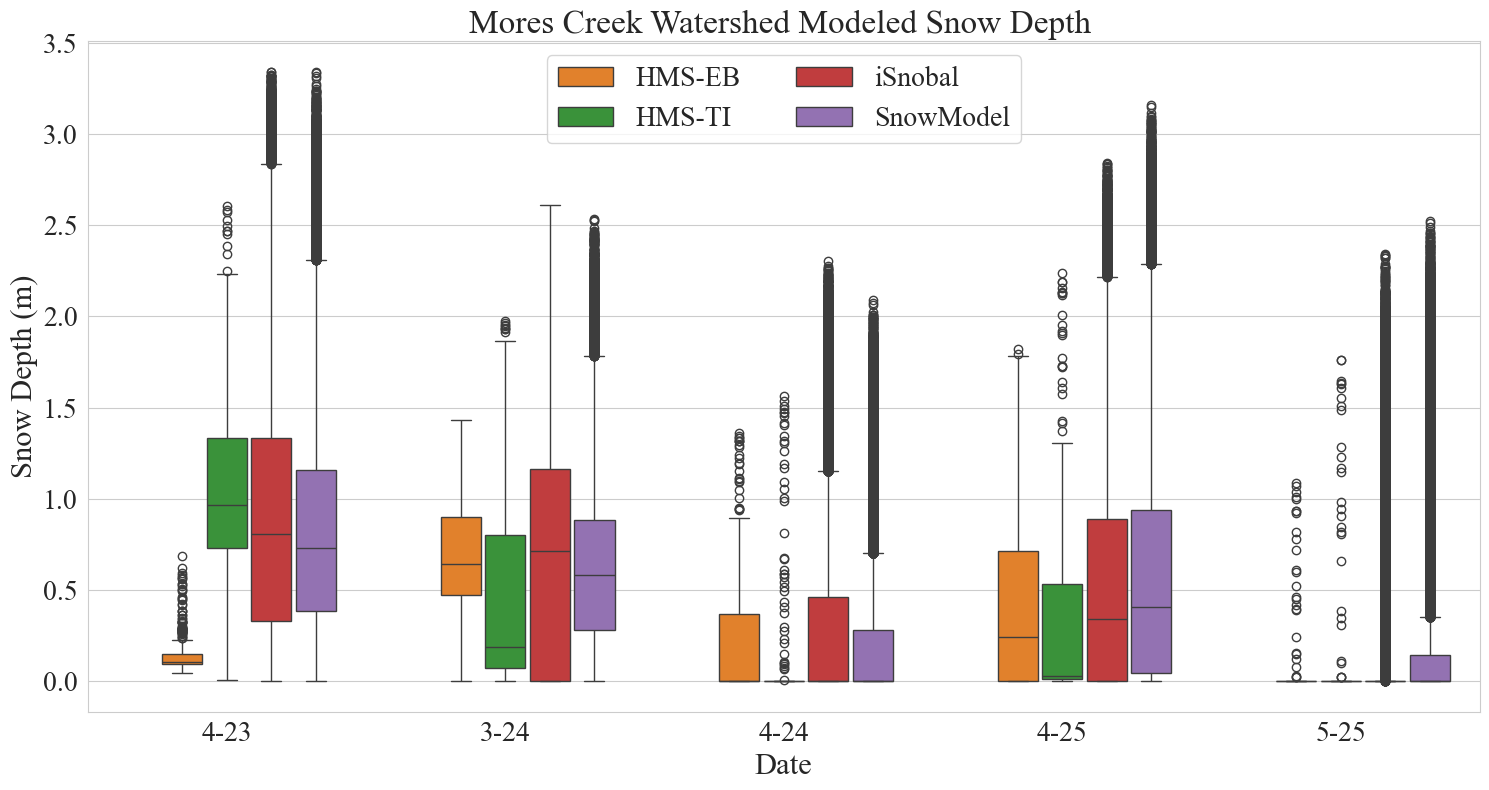

In [237]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(15, 8))
order = ['','HMS-EB', 'HMS-TI', 'iSnobal', 'SnowModel']

sns.boxplot(
    data=Task1_basin,
    x = "Date",
    y= "Snow Depth",
    hue = "Model",
   hue_order = order,
    gap = 0.1)


ax.set_xlabel('Date', fontsize = 22)
ax.set_ylabel('Snow Depth (m)', fontsize = 22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.set_xticklabels(['4-23', '3-24', '4-24', '4-25', '5-25'])
ax.legend(prop={'size': 20}, ncol = 2) # Sets exact font size
ax.set_title("Mores Creek Watershed Modeled Snow Depth ", fontsize=24)



plt.tight_layout()

plt.savefig("C:/Users/RDCRLSMC/Desktop/SIRO/docs/figs/basin_distributions.png", dpi = 300)
plt.show() 

### Add Elevation to DF


In [60]:
dem_fp = "C:/Users/RDCRLSMC/Desktop/SIRO/data/shapes/merged_32611_clip.tif"


dfs = []
with rasterio.open(dem_fp) as src:
    dem = src.read(1)
    dem = dem[dem != 0]
    low_thr, high_thr = np.percentile(dem, [33.33, 66.66])
    print(low_thr, high_thr)
    print(dem.min(), dem.max())

for key in task1.keys():
    task1_clip = task1[key]['basin_clip']
    task2_clip = task2[key]['basin_clip']
    
    MCS = {"Task 1":task1_clip, "Task 2":task2_clip}
    
    for task, raster_list in MCS.items():
        for name, model_data in raster_list.items():
                with rasterio.open(model_data) as src:
                    ref_shape = (src.height, src.width)
                    ref_transform = src.transform 
                    data = src.read(1)
                    # mask = (data == -9999)
                    # data_masked = np.ma.array(data, mask=mask)
                    # flattened = data_masked.compressed()
                    # flattened = flattened[flattened < 5]
                    
                elevation_aligned = np.empty(ref_shape, dtype=np.float32)
    
                with rasterio.open(dem_fp) as dem:
                    reproject(
                        source=dem.read(1),
                        destination=elevation_aligned,
                        src_transform=dem.transform,
                        src_crs=dem.crs,
                        dst_transform=ref_transform,
                        dst_crs="EPSG:32611",
                        resampling=Resampling.nearest
                    )
                    
                    invalid_snow = (data == -9999) | (data >= 5)
                    invalid_elev = (elevation_aligned == 0)
                    master_mask = invalid_snow | invalid_elev

                    data_masked = np.ma.array(data, mask=master_mask)
                    elevation_masked = np.ma.array(elevation_aligned, mask=master_mask)
                    
                    # Compress them (they are guaranteed to be the same length now)
                    flattened = data_masked.compressed()
                    elevation_flat = elevation_masked.compressed()
                
                    # elevation_masked = np.ma.array(elevation_aligned, mask=mask)
                    # elevation_masked.mask |= (elevation_masked == 0)
                    # elevation_flat = elevation_masked.compressed()
                    elev_class = np.where(
                                elevation_flat < low_thr, "low",
                                np.where(elevation_flat < high_thr, "middle", "high")
                            )
                    df = pd.DataFrame({
                    "Task":task,
                    "Date":key,
                    "Model": name,        # this column will store model names
                    "Snow Depth": flattened,
                    "Elevation": elevation_flat,
                    "Elevation Class": elev_class
                    })
                    dfs.append(df)
                
    
snow_depth = pd.concat(dfs, ignore_index=True)    

1395.2159423828125 1618.0367918945312
940.4415 2473.43


In [61]:
Task1_basin = snow_depth[snow_depth['Task'] =='Task 1']
Task2_basin = snow_depth[snow_depth['Task'] =='Task 2']

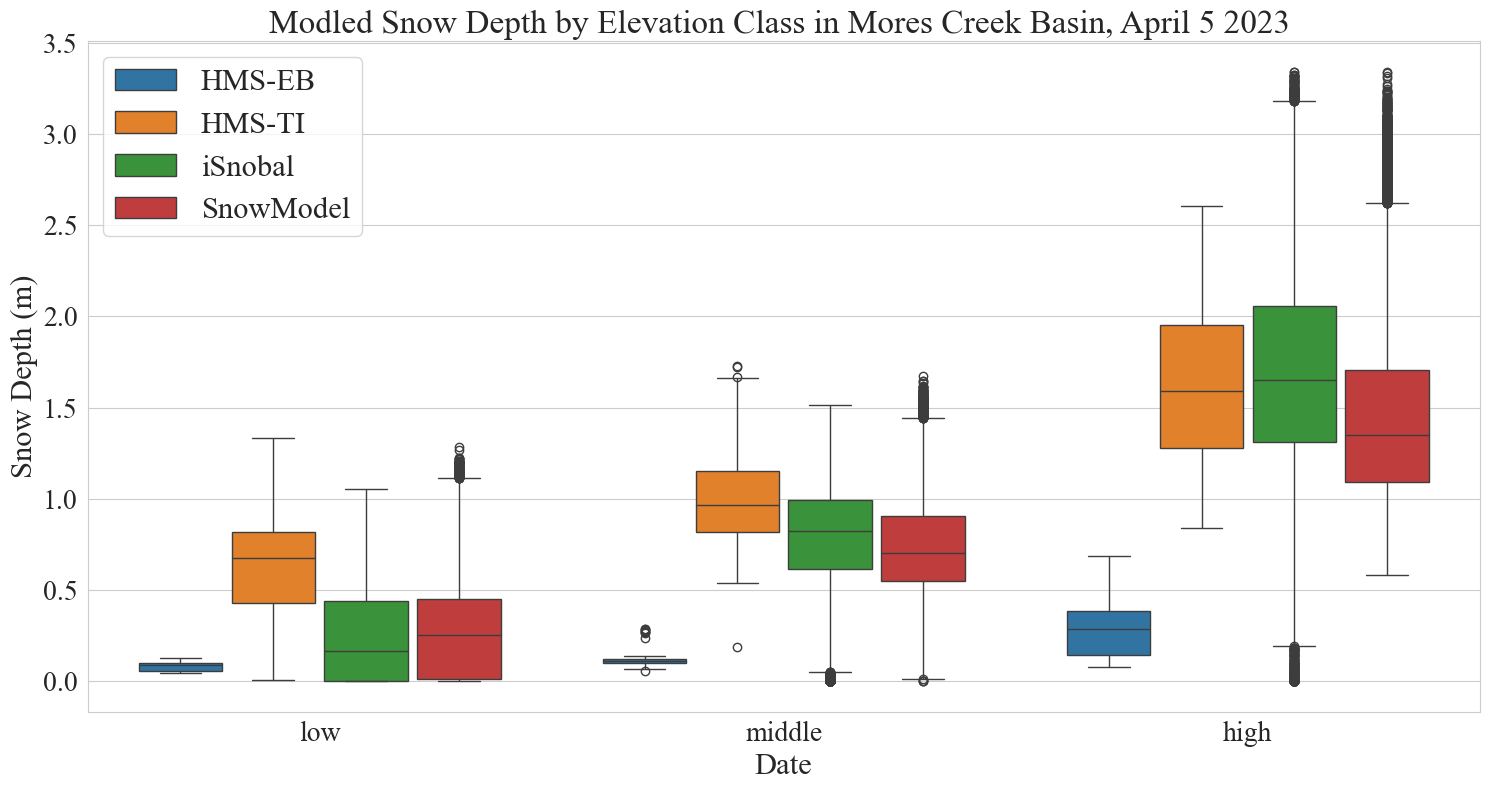

In [62]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(
    data=Task1_basin[Task1_basin['Date'] =='20230405'],
    x = "Elevation Class",
    y= "Snow Depth",
    order = ['low', 'middle', 'high'],
    hue = "Model",
    gap = 0.1)


ax.set_xlabel('Date', fontsize = 22)
ax.set_ylabel('Snow Depth (m)', fontsize = 22)
ax.tick_params(axis='both', which='major', labelsize=20)
ax.legend(prop={'size': 22}) # Sets exact font size
ax.set_title("Modled Snow Depth by Elevation Class in Mores Creek Basin, April 5 2023 ", fontsize=24)



plt.tight_layout()
plt.show() 

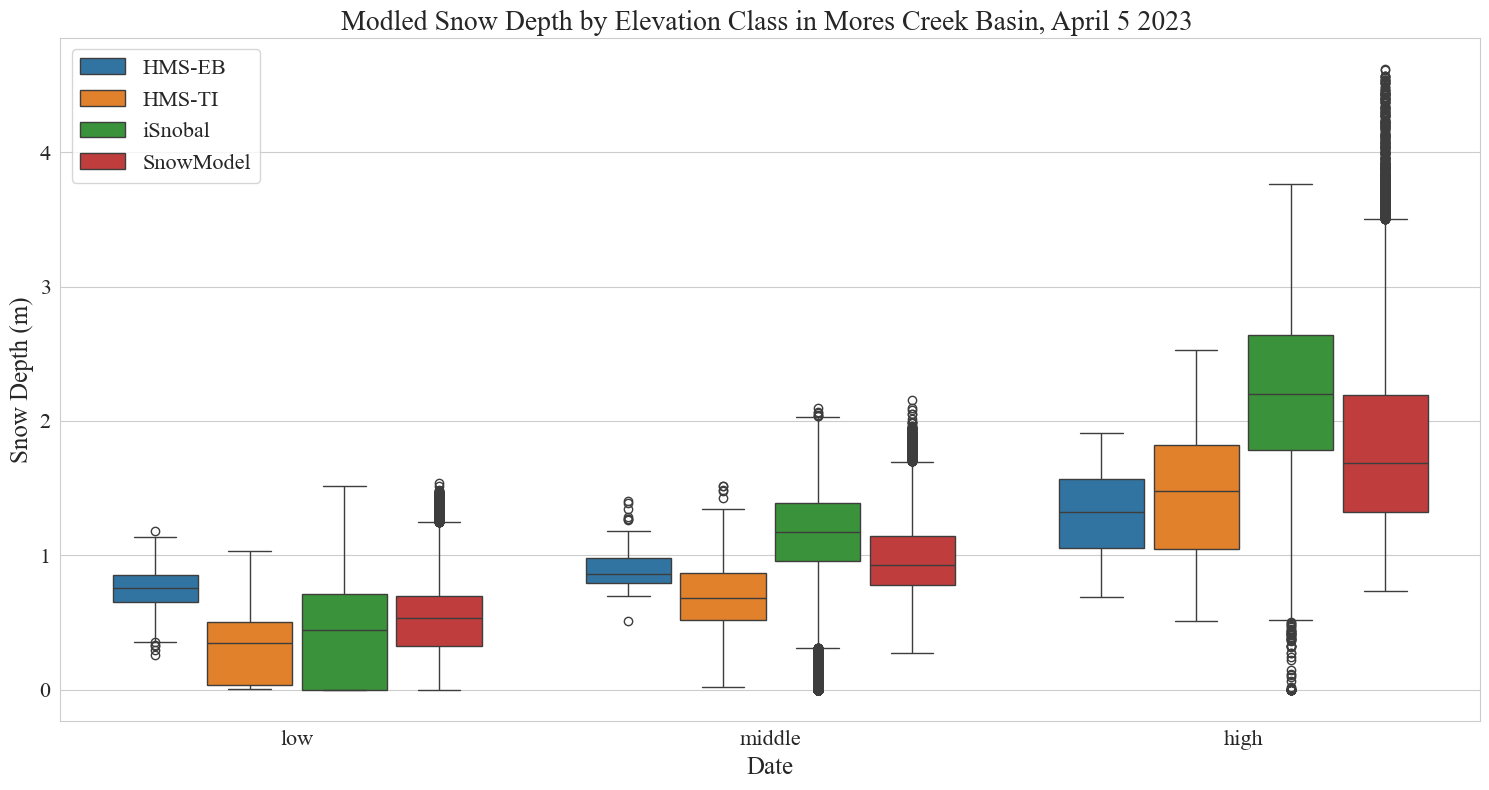

In [63]:
plt.rcParams['font.family'] = 'serif'
plt.rcParams['font.serif'] = ['Times New Roman'] + plt.rcParams['font.serif']

fig, ax = plt.subplots(figsize=(15, 8))

sns.boxplot(
    data=Task2_basin[Task2_basin['Date'] =='20230405'],
    x = "Elevation Class",
    y= "Snow Depth",
    order = ['low', 'middle', 'high'],
    hue = "Model",
    gap = 0.1)


ax.set_xlabel('Date', fontsize = 18)
ax.set_ylabel('Snow Depth (m)', fontsize = 18)
ax.tick_params(axis='both', which='major', labelsize=16)
ax.legend(prop={'size': 16}) # Sets exact font size
ax.set_title("Modled Snow Depth by Elevation Class in Mores Creek Basin, April 5 2023 ", fontsize=20)



plt.tight_layout()
plt.show() 

940.4415


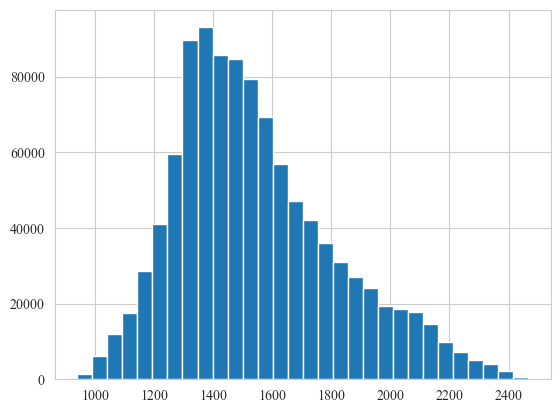

In [64]:

plt.hist(Task1_basin["Elevation"],bins=30)
print(Task1_basin["Elevation"].min())

C:\Users\RDCRLSMC\AppData\Local\Temp\2\ipykernel_37500\792060709.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Task1_basin['Elevation Bin'] = pd.cut(Task1_basin['Elevation'], bins=100)
C:\Users\RDCRLSMC\AppData\Local\Temp\2\ipykernel_37500\792060709.py:9: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  Task1_basin['Elevation Plot'] = Task1_basin['Elevation Bin'].apply(lambda x: x.mid).astype(float)


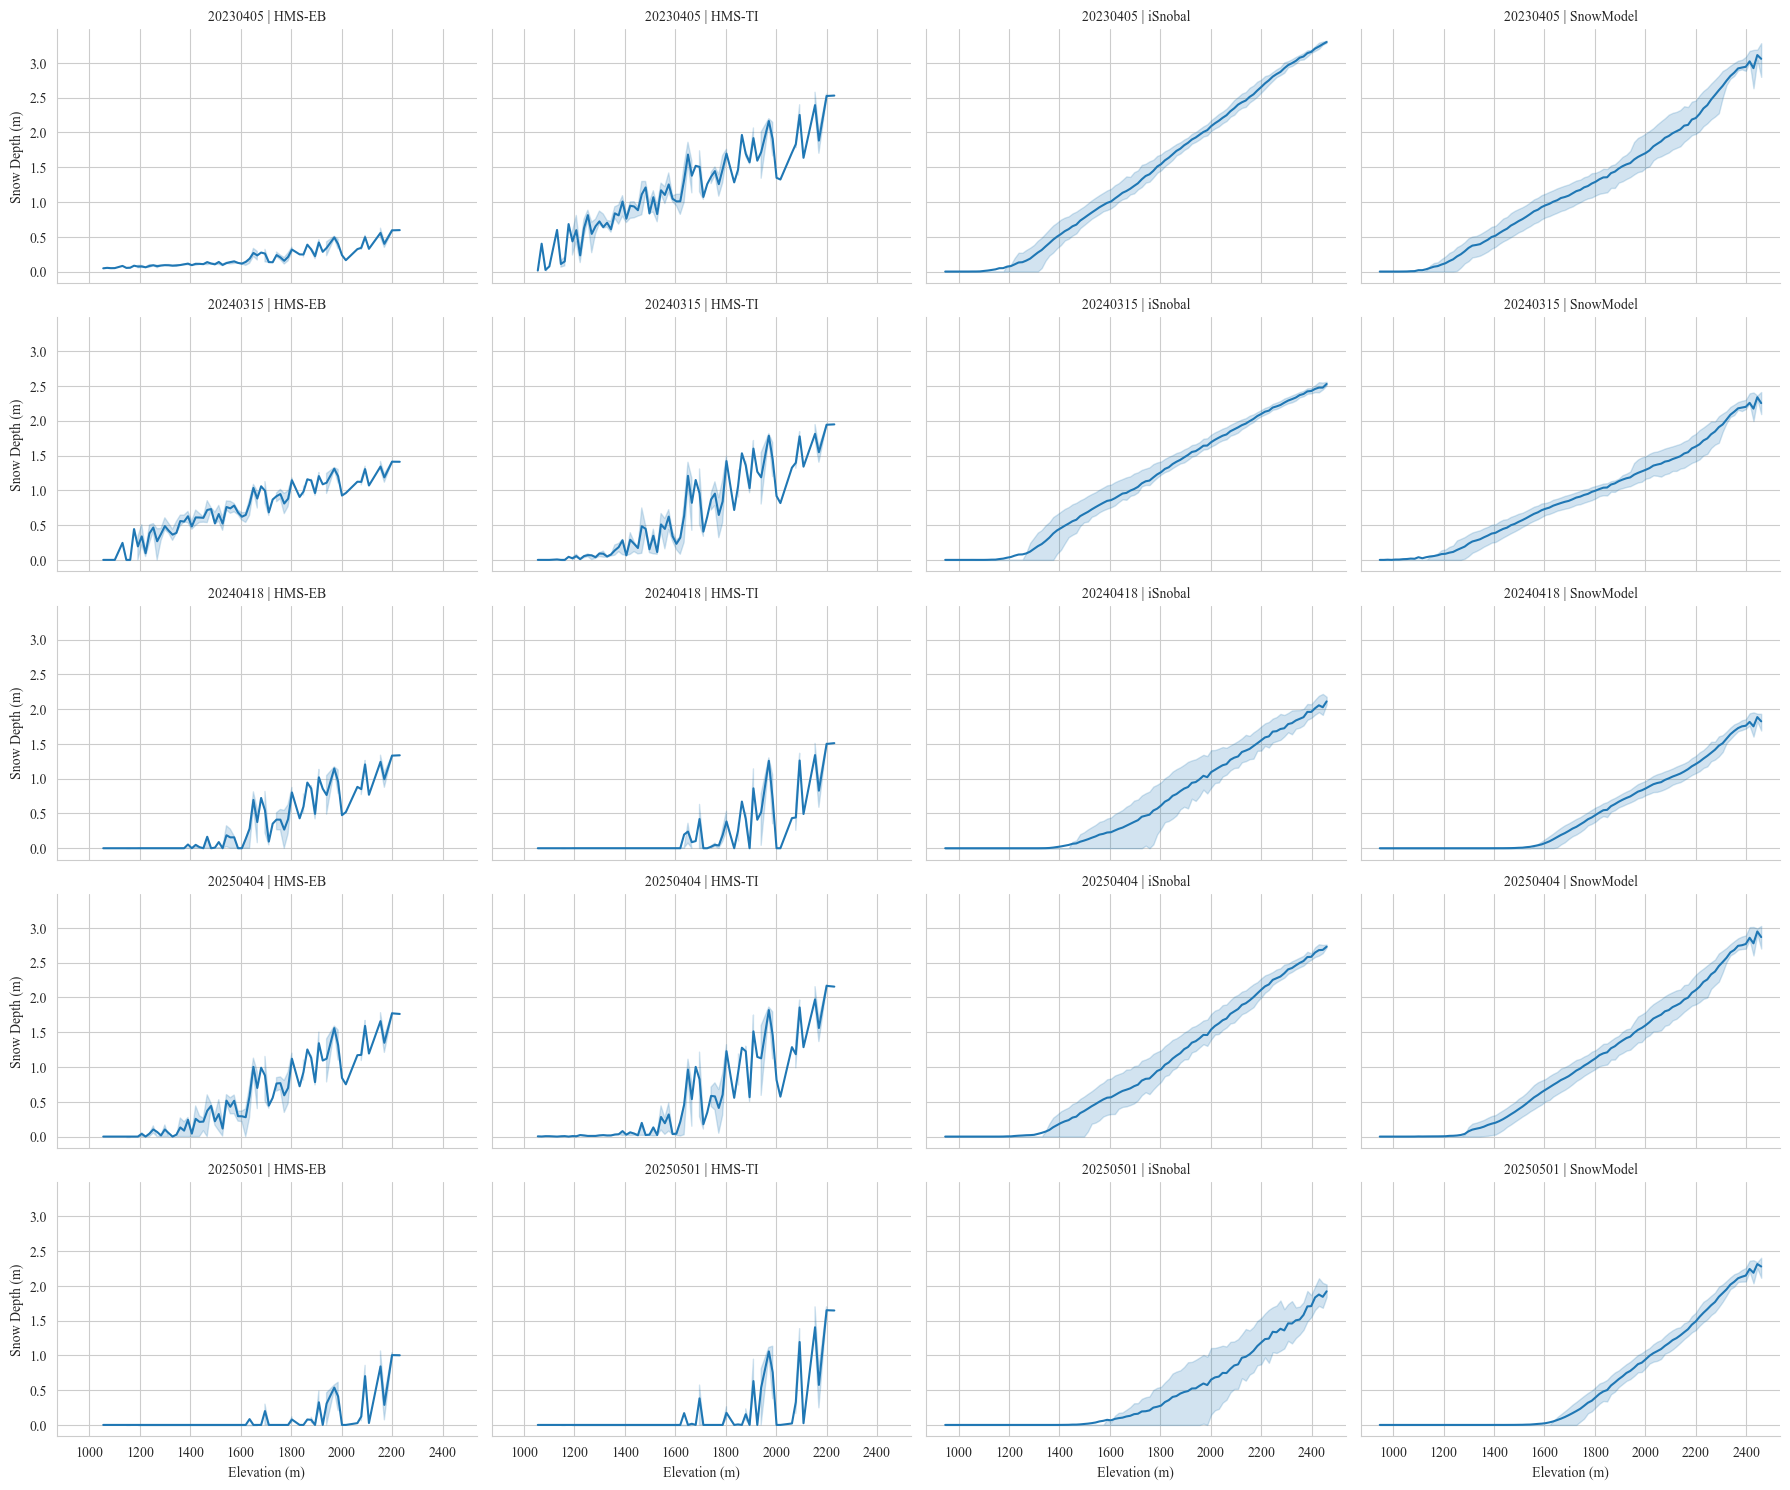

In [65]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Create the bins using your actual combined dataframe 'snow_depth'
Task1_basin['Elevation Bin'] = pd.cut(Task1_basin['Elevation'], bins=100)

# 2. Extract the numeric midpoint of the bin for the X-axis plotting
Task1_basin['Elevation Plot'] = Task1_basin['Elevation Bin'].apply(lambda x: x.mid).astype(float)

# 3. Create the matrix of ribbon plots
g = sns.relplot(
    data=Task1_basin,
    x='Elevation Plot',
    y='Snow Depth',
    row='Date',       # Rows will be the Date
    col='Model',      # Columns will be the Model
    kind='line',
    
    # This plots the mean as the single line
    estimator='mean', 
    
    # errorbar=('pi', 50) means "Percentile Interval covering 50% of the data". 
    # This automatically calculates the 25th to 75th percentile (the IQR!) and shades it.
    errorbar=('pi', 50), 
    
    height=3,
    aspect=1.5,
    facet_kws={'sharey': True, 'sharex': True}
)

# Optional: Clean up the titles of each subplot so they are easier to read
g.set_titles(row_template="{row_name}", col_template="{col_name}")
g.set_axis_labels("Elevation (m)", "Snow Depth (m)")

plt.show()


In [37]:
binned_stats

Date      Model  
20230405  iSnobal    0.906833
Name: Snow Depth, dtype: float32

In [17]:
d20230405 = Task1_basin[Task1_basin['Date'] =='20230405']
d20240315 = Task1_basin[Task1_basin['Date'] =='20240315']
d20240418 = Task1_basin[Task1_basin['Date'] =='20240418']
d20250404 = Task1_basin[Task1_basin['Date'] =='20250404']
d20250501 = Task1_basin[Task1_basin['Date'] =='20250501']

In [65]:
d20250501

,Task,Date,Model,Snow Depth,Elevation,Elevation Class
1651160,Task 1,20250501,HMS-EB,0.0,1589.458496,middle
1651161,Task 1,20250501,HMS-EB,0.0,1749.169922,high
1651162,Task 1,20250501,HMS-EB,0.0,733.742188,low
1651163,Task 1,20250501,HMS-EB,0.0,1642.366089,high
1651164,Task 1,20250501,HMS-EB,0.0,1975.173096,high
...,...,...,...,...,...,...
1857550,Task 1,20250501,SnowModel,0.0,1435.942139,middle
1857551,Task 1,20250501,SnowModel,0.0,1425.988892,middle
1857552,Task 1,20250501,SnowModel,0.0,1346.552246,low
1857553,Task 1,20250501,SnowModel,0.0,1235.156372,low


<Axes: xlabel='Elevation', ylabel='Snow Depth'>

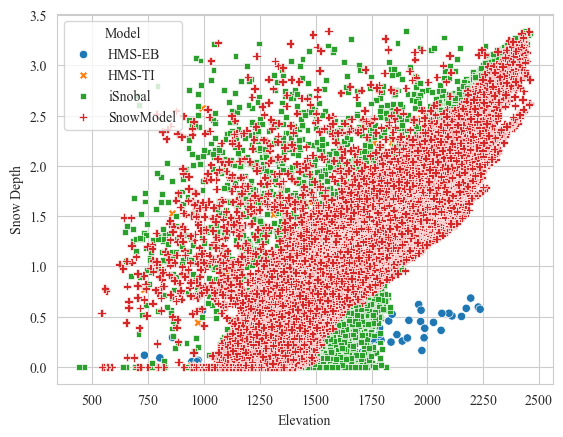

In [68]:
sns.scatterplot(data=d20230405, x = "Elevation", y = "Snow Depth", style = "Model", hue = "Model")

In [ ]:
sns.displot(d20230405, x="Elevation", hue="species", kind="kde", multiple="stack")


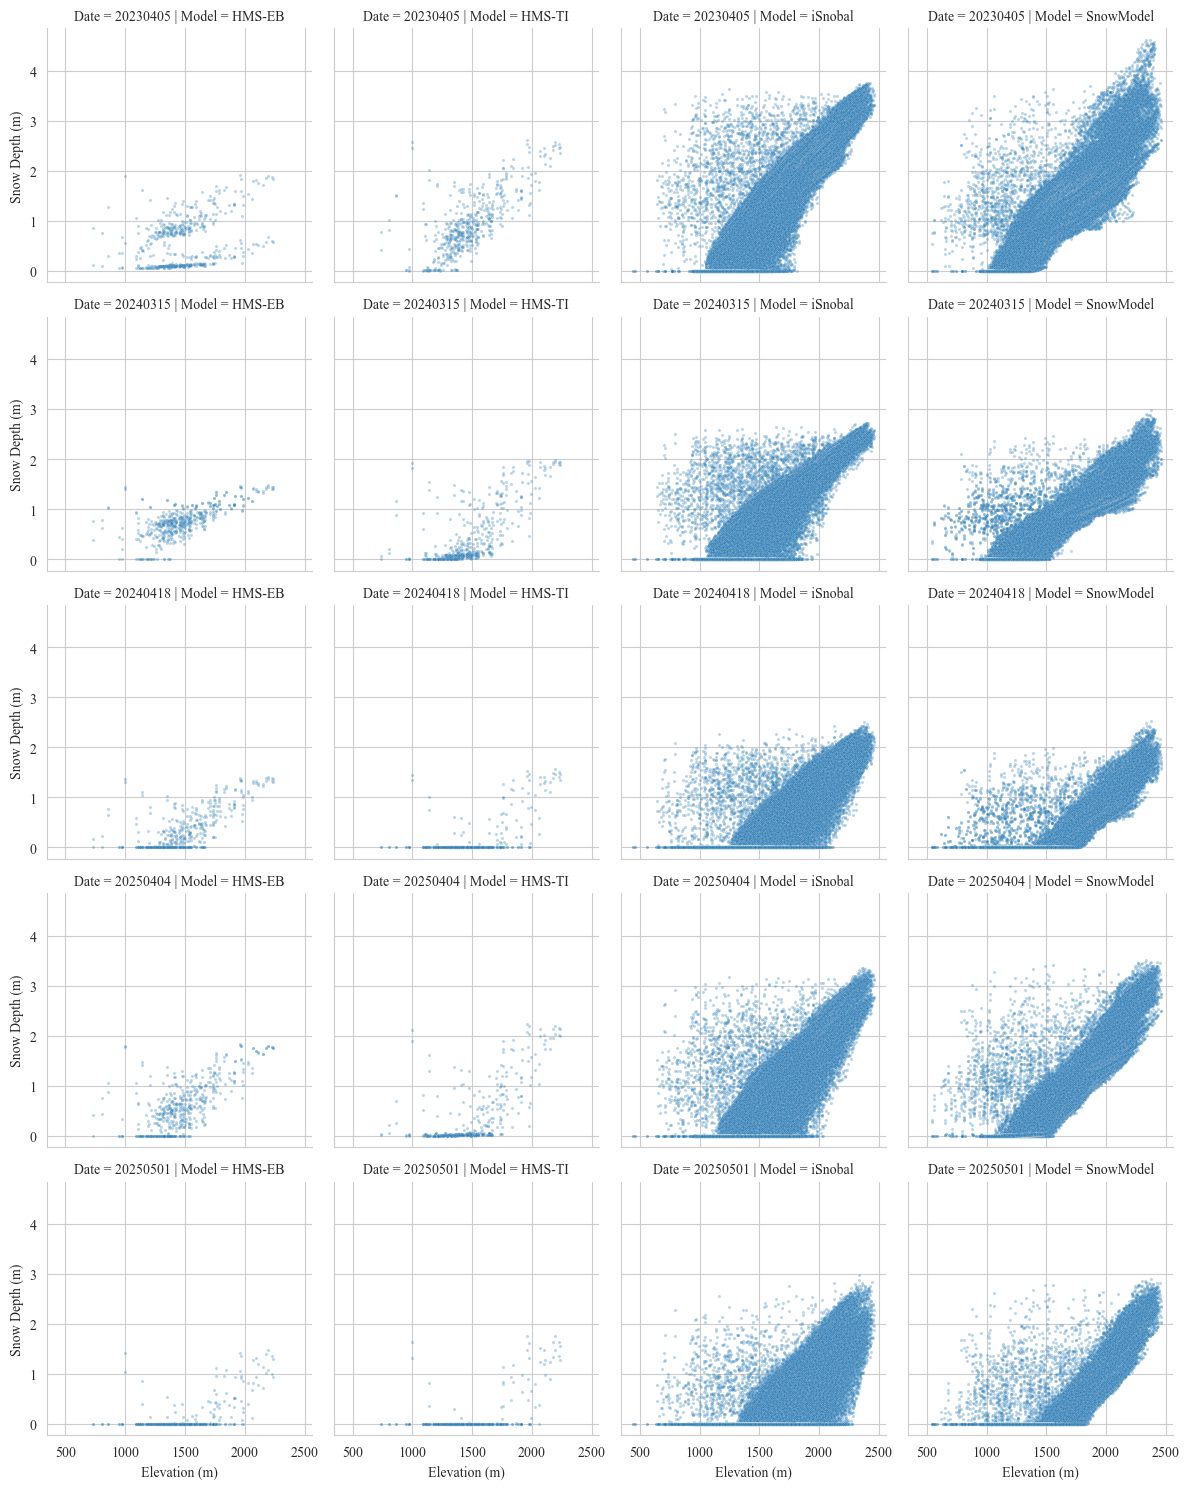

In [15]:
import seaborn as sns
import matplotlib.pyplot as plt

g = sns.FacetGrid(
    snow_depth,
    row="Date",
    col="Model",
    height=3,
    sharex=True,
    sharey=True
)

g.map_dataframe(
    sns.scatterplot,
    x="Elevation",
    y="Snow Depth",
    s=5,
    alpha=0.3
)

g.set_axis_labels("Elevation (m)", "Snow Depth (m)")
plt.tight_layout()
plt.show()

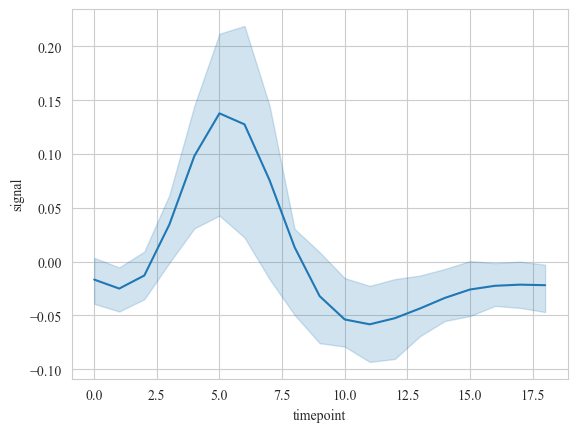

In [10]:

# Load example data
fmri = sns.load_dataset("fmri")

# Plot with mean and IQR (25th-75th percentile)
sns.lineplot(
    data=fmri, 
    x="timepoint", 
    y="signal",
    estimator='mean', # or 'median'
    errorbar=lambda x: (np.quantile(x, 0.25), np.quantile(x, 0.75))
)

plt.show()


In [30]:
fmri

,subject,timepoint,event,region,signal
0,s13,18,stim,parietal,-0.017552
1,s5,14,stim,parietal,-0.080883
2,s12,18,stim,parietal,-0.081033
3,s11,18,stim,parietal,-0.046134
4,s10,18,stim,parietal,-0.037970
...,...,...,...,...,...
1059,s0,8,cue,frontal,0.018165
1060,s13,7,cue,frontal,-0.029130
1061,s12,7,cue,frontal,-0.004939
1062,s11,7,cue,frontal,-0.025367


In [32]:
print(fmri["signal"].nunique())
print(fmri["timepoint"].nunique())

1064
19


KeyboardInterrupt: 

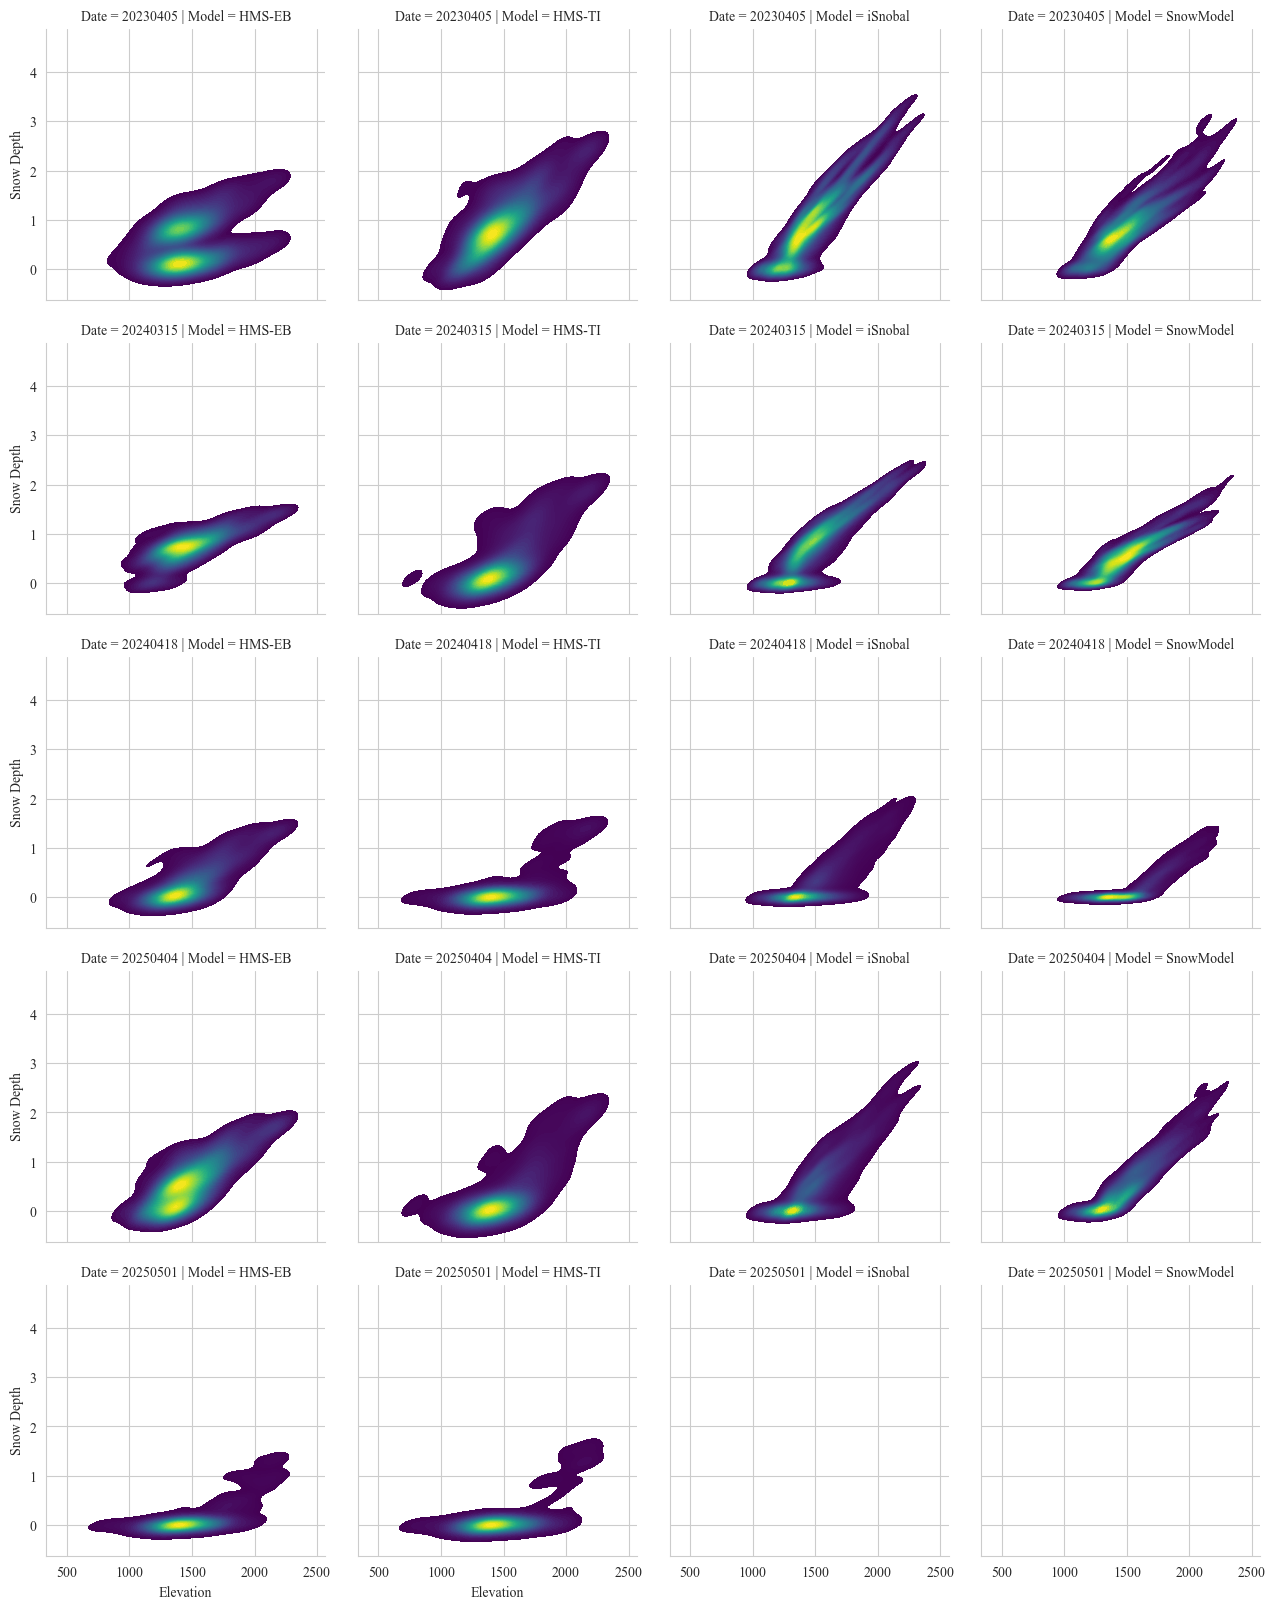

In [24]:
# g = sns.FacetGrid(
#     snow_depth,
#     row="Date",
#     col="Model",
#     height=3.2,
#     sharex=True,
#     sharey=True
# )
# 
# g.map_dataframe(
#     sns.kdeplot,
#     x="Elevation",
#     y="Snow Depth",
#     fill=True,
#     cmap="viridis",
#     levels=50,
#     thresh=0.05
# )
# 
# g.set_axis_labels("Elevation (m)", "Snow Depth (m)")
# #g.set_titles(row_template="{row_name}", col_template="{col_name}")
# 
# plt.tight_layout()
# plt.show()